# 实验四、 基于PCA的特征脸 (Eigen Face) 识别

姓名：王智颍

学号：3238507069

班级：3班

日期：2025-12-26

主成分分析 (Principal Component Analysis, PCA)，在图像识别、高维度数据降维处理 以及 图片去噪声等领域中有着很强的应用性。该算法主要通过特征分解，求取较大的特征向量来对原始数据进行线性变换，以此得到数据的低维表示，以及重构原始数据。

最近在机器学习领域的进展已经使得面部识别不再是一个难题。但在之前，研究人员已经进行了各种尝试并开发了各种技能，以使计算机能够识别人脸。其中一个早期尝试并取得适度成功的是特征脸（eigenface），它基于PCA技术。

在此实验中，我们将看到我们如何能够使用一些简单的线性代数技术，比如主成分分析，来构建一个原始的面部识别系统。

完成这个实验后，你将了解：

- 特征脸技术的发展历程
- 如何使用主成分分析从图像数据集中提取特征图像
- 如何将任何图像表示为特征图像的加权和
- 如何通过主成分的权重比较图像的相似性


In [1]:
# 导入相关库函数
import os
import numpy as np
import matplotlib.pyplot as plt

在1987年，Sirovich和Kirby的一篇论文提出了一个观点，即所有人脸图像可以被视为少数“关键图片”的加权和。Sirovich和Kirby将这些关键图片称为“eigenpictures”，因为它们是人脸图像平均值减去后的协方差矩阵的特征向量。在他们的论文中，确实提供了人脸图像数据集的主成分分析算法，并且加权和中使用的权重确实对应于人脸图像投影到每个eigenpicture上。

1991年，Turk和Pentland的一篇论文创造了“eigenface”这个术语。他们在Sirovich和Kirby的基础上进一步发展，使用权重和eigenpictures作为识别人脸的特征特征。Turk和Pentland的论文提出了一种计算eigenpictures的内存高效方法。它还提出了一个人脸识别系统如何操作的算法，包括如何更新系统以包含新的面孔，以及如何将其与视频捕捉系统结合。同一篇论文还指出，eigenface的概念可以帮助重建部分受阻的图片。


## 1. 读取数据，并绘制照片

In [2]:
# read in the pictures
facePath = 'dataset/orl-faces/'

facesDict = {name: [] for name in os.listdir(facePath)}
for personId in sorted(facesDict.keys()):
    for fId in range(1, 11):
        fData = plt.imread(facePath + personId + f'/{fId:02d}.png')
        fData = fData[:, :, 1]
        facesDict[personId].append(fData)

imgHeight, imgWidth = facesDict[personId][0].shape
featDim = imgWidth * imgHeight          # 特征数 10304
featDim2D = (imgHeight, imgWidth)       # (112, 92)

totalPersonNum = len(facesDict.keys())
facePerPerson = len(facesDict['s01'])

print(f'The number of persons in this dataset is: {totalPersonNum}.')
print(f'The number of faces per person is: {facePerPerson}.')
print(f'The shape of the face image: Width ({imgWidth}),  Height ({imgHeight}).')

The number of persons in this dataset is: 40.
The number of faces per person is: 10.
The shape of the face image: Width (92),  Height (112).


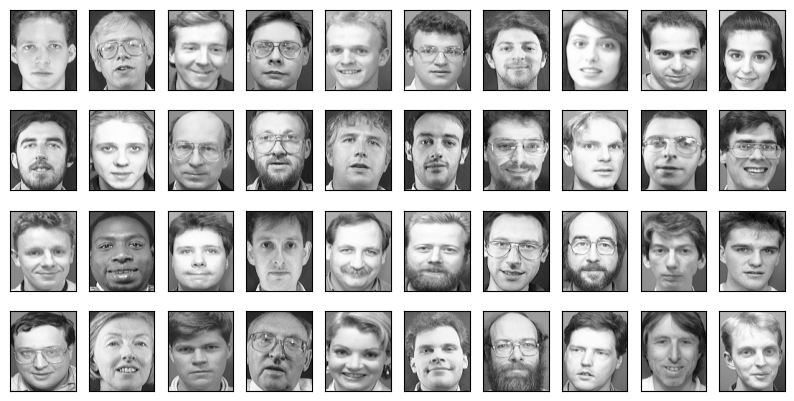

In [3]:
# draw the pictures

fig, axes = plt.subplots(4, 10, figsize=(10, 5))
for ax, personId in zip(axes.flatten(), sorted(facesDict.keys())):
    ax.imshow(facesDict[personId][0], cmap='gray')
    ax.set(xticks=[], yticks=[])


本测试中，总共有40个测试者，其中每个人有10张照片。上图绘制出了每一个测试者的一张照片；下图绘制其中一个测试者的10张照片。

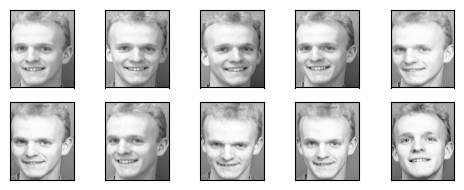

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(5, 2))

personId = 's05'

# TODO
## ---------- 请在以下输入代码，输出一个测试者的所有照片 ---------- ##
# 遍历2行5列的子图和该测试者的10张照片
for ax, face in zip(axes.flatten(), facesDict[personId]):
    # 以灰度模式显示单张人脸照片
    ax.imshow(face, cmap='gray')
    # 隐藏坐标轴刻度，让图片展示更整洁
    ax.set(xticks=[], yticks=[])
# 自动调整子图间距，避免图片重叠
plt.tight_layout()
# 显示绘制好的图片
plt.show()


## 2. 构建大矩阵 `bigA` 以及 平均脸 (meanFace)

首先，我们将所有的数据拼起来，构成一个大矩阵 `bigA`，它存储了所有的训练集中的脸的数据。

为了说明使用特征脸进行识别的能力，我们希望在生成特征脸之前保留一些图片。我们保留一个人的所有图片以及另一个人的一张图片作为我们的测试集。剩余的图片被向量化并转换成一个 `2D` 的 `numpy` 数组。


因此，`bigA` 具有 `(10304 x 389)`的维度；其中，`10304` 是图片拉伸为一维向量的维度，`389` 表示大矩阵中总的图片数目。

平均脸 (meanFace) 表示数据集中所有脸的平均值，也可以通过图片绘制出来。

In [12]:
## 构建大矩阵 bigA

excludePersonId = 's40'     # 保留 s40 这个测试者的图片作测试集
excludeFaceIds = ('s39', 9)    # 剔除 s39 的第10张照片作测试集

bigA = np.zeros((featDim, (totalPersonNum-1) * facePerPerson - 1))
faceLabels = []

idx = 0
for personId in sorted(facesDict.keys()):
    if personId == excludePersonId:
        continue
    for ii, faceData in enumerate(facesDict[personId]):
        if personId == excludeFaceIds[0] and ii == excludeFaceIds[1]:
            continue
        bigA[:, idx] = faceData.flatten()
        faceLabels.append(personId + "/" + f"{ii}")
        idx += 1

# TODO
## ---------- 请在以下输入代码，计算平均脸、平均后的数据集 ---------- ##

meanFace = np.mean(bigA, axis=1)
meanA = bigA - meanFace.flatten().reshape(-1, 1)        # 减去平均脸后的数据集

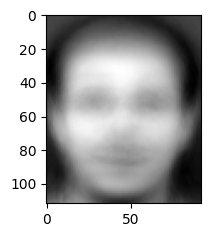

In [13]:
# 绘制平均脸
fig, ax = plt.subplots(figsize=(2, 3.5))
ax.imshow(meanFace.reshape((imgHeight, imgWidth)), cmap='gray');

## 2. PCA 求解

假设 $n$ 为数据维度，$m$为训练集中的样本数(脸的数目), 采用 $A$ 标记测试训练集 `bigA`，则

PCA算法的步骤如下：

1) 计算协方差矩阵 $C = \frac{1}{m-1} A  A^{T}$
2) 求出协方差矩阵 $C$ 的特征值和对应的特征向量
3) 将特征向量对用的特征值按照从大到小的顺序排列成矩阵，取前 $k$ 列组成矩阵 $U$。$U$的每一列对应着特征脸。
4) 求解原始图片在特征空间中的低维度表示: $Y = U^{T}  A$
5) 获得原始数据集 $A$ 的重构数据 $A' = U  Y$

In [14]:
# TODO
## ---------- 请在以下输入代码 ---------- ##
## 1. 协方差矩阵 C
## 2. 特征分解 (eigVals, eigVecs)
m = meanA.shape[1] 
C = (1 / (m - 1)) * np.dot(meanA, meanA.T)
eigVals, eigVecs = np.linalg.eig(C)


特征值`eigVals`代表着对应特征向量的对数据方差的概况能力，绘制特征值的累积方差共享率可以帮助我们决定选取的特征向量数目 $k$。


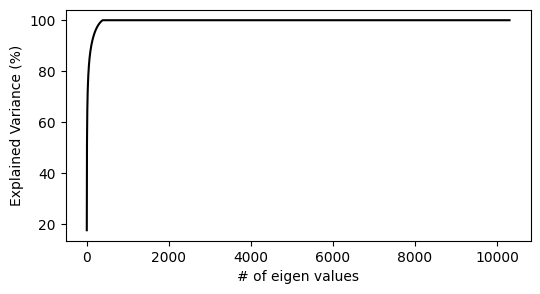

In [17]:
# TODO
## ---------- 请在以下输入代码, 计算特征值累积曲线 ---------- ##
# 1. 对特征值进行降序排序（确保从大到小）
sorted_indices = np.argsort(eigVals)[::-1]
sorted_eigVals = eigVals[sorted_indices]

# 2. 计算特征值的累积和与总和的比值（即累积解释方差比例）
cum_sum = np.cumsum(sorted_eigVals)
total_sum = np.sum(sorted_eigVals)
cumPer = (cum_sum / total_sum) * 100  # 转换为百分比形式

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.arange(len(eigVals)), cumPer, color='k')
ax.set_xlabel('# of eigen values')
ax.set_ylabel('Explained Variance (%)');

如果选取 $k=300$， 则累积特征值对总数据方差的解释度为：

In [18]:
# TODO
## ---------- 请在以下输入代码, 输出方差贡献度 ---------- ##
k = 300
cum_variance_300 = cumPer[k-1]

# 3. 格式化输出结果，保留2位小数
print(f"选取k={k}时，累积特征值的方差解释度为：{cum_variance_300:.2f}%")

选取k=300时，累积特征值的方差解释度为：98.57-0.00j%


## 3. 绘制特征脸

PCA结果中提取特征脸并将其存储为numpy数组。请注意，特征脸是以矩阵的列形式存储的。如果我们要显示它，可以将其转换回2D。在下面，我们展示了一些特征脸，看看它们是什么样子的：

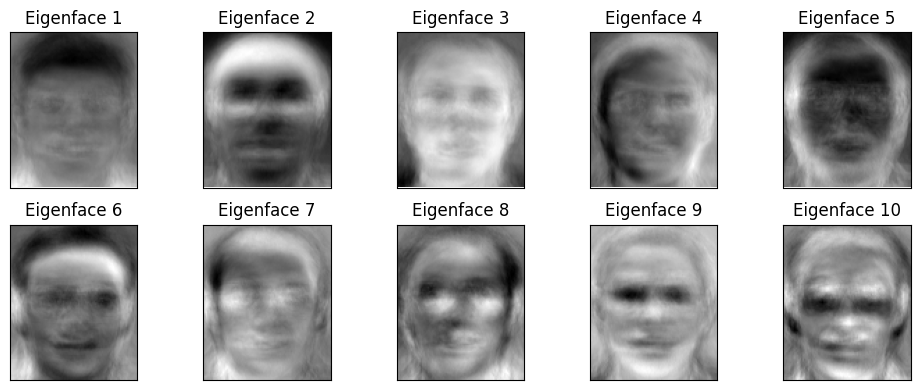

In [22]:
# ---------- 绘制前10个特征脸 ---------- ##
# 1. 先对特征向量按特征值降序排序（和之前特征值排序保持一致）
# 关键修复：先提取特征值实部再排序，避免复数干扰
sorted_indices = np.argsort(np.real(eigVals))[::-1]
sorted_eigVecs = eigVecs[:, sorted_indices]

# 2. 核心修复：提取特征向量实部，剔除数值计算产生的虚部
# 复数无法被matplotlib.imshow处理，必须转换为实数
sorted_eigVecs = np.real(sorted_eigVecs)

# 3. 提取前k=10个特征向量（特征脸），并转换为图像尺寸
top_k_eigenfaces = sorted_eigVecs[:, :10]  # 取前10列（前10个特征脸）
eigenfaces_2d = [face.reshape(featDim2D) for face in top_k_eigenfaces.T]

# 4. 创建2行5列的子图（共10个特征脸）
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

# 5. 遍历子图和特征脸，绘制图像
for ax, eigenface in zip(axes.flatten(), eigenfaces_2d):
    # 显示特征脸（灰度模式）
    ax.imshow(eigenface, cmap='gray')
    # 隐藏坐标轴刻度，提升美观度
    ax.set(xticks=[], yticks=[])
    # 标注特征脸序号（简化版序号计算，更稳定）
    ax.set_title(f'Eigenface {list(axes.flatten()).index(ax)+1}')

# 6. 调整子图间距，避免重叠
plt.tight_layout()
# 7. 显示图像
plt.show()



从这张图片中，我们可以看到特征脸是模糊的人脸，但确实每个特征脸都包含了一些可以用来构建图像的面部特征。

## 4. 重构原始图片 (降噪 denoising)

不同的特征脸个数，对应着不同精度的数据重构，为此，我们选取 $k=100$ 以及 $k=300$两种情况进行图片重构。 

1) 首先确定$k$个特征脸构成的特征空间$U$，
2) 随后将原始图片投影到PCA变换后的特征空间内，可以得到低维度的数据表达 $E = U^{T}A$.
3) 最后利用 $A' = U E$

首先，测试 `k=100` 的情况：

In [23]:
k1 = 100

# TODO
# 1. 构建k=100的特征空间U1（取前100个降序排列的特征向量）
sorted_indices = np.argsort(eigVals)[::-1]  # 特征值降序索引
U1 = eigVecs[:, sorted_indices[:k1]]       # 取前100列作为特征空间

# 2. 计算原始去中心化数据在特征空间的低维表示E1
# E1 = U1^T * meanA  (维度：100 x 389)
E1 = np.dot(U1.T, meanA)

# 3. 重构去中心化的数据
rev_meanA1 = np.dot(U1, E1)
# 4. 加回平均脸，得到最终重构的图片（恢复原始数据尺度）
revA1 = rev_meanA1 + meanFace.flatten().reshape(-1, 1)

# 补充：处理数值计算产生的虚部（若有）
U1 = np.real(U1)
E1 = np.real(E1)
revA1 = np.real(revA1)

随后是 `k=300` 的情况：

In [24]:
k2 = 300

# TODO
# 1. 构建k=300的特征空间U2（取前300个降序排列的特征向量）
sorted_indices = np.argsort(eigVals)[::-1]  # 特征值降序索引
U2 = eigVecs[:, sorted_indices[:k2]]       # 取前300列作为特征空间

# 2. 计算原始去中心化数据在特征空间的低维表示E2
# E2 = U2^T * meanA  (维度：300 x 389)
E2 = np.dot(U2.T, meanA)

# 3. 重构去中心化的数据
rev_meanA2 = np.dot(U2, E2)
# 4. 加回平均脸，得到最终重构的图片（恢复原始数据尺度）
revA2 = rev_meanA2 + meanFace.flatten().reshape(-1, 1)

# 补充：处理数值计算产生的虚部（若有）
U2 = np.real(U2)
E2 = np.real(E2)
revA2 = np.real(revA2)

Text(0, 0.5, 'k=100')

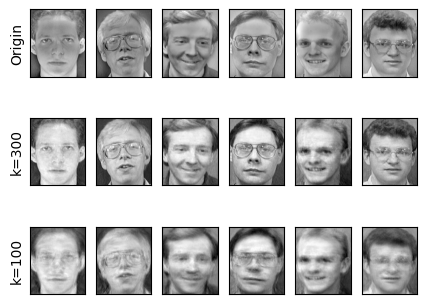

In [25]:
# 对比不同数量的特征脸时，重构图片的精度

fig, axes = plt.subplots(3, 6, figsize=(5, 4))

for ii in range(0, 6):
    fId = ii*10
    # 原始图片
    axes[0, ii].imshow(meanA[:, fId].reshape(featDim2D), cmap='gray')
    axes[0, ii].xaxis.set_major_locator(plt.NullLocator()); axes[0, ii].yaxis.set_major_locator(plt.NullLocator())
    # 重构图片 (k=300)
    axes[1, ii].imshow(revA2[:, fId].reshape(featDim2D), cmap='gray')
    axes[1, ii].xaxis.set_major_locator(plt.NullLocator()); axes[1, ii].yaxis.set_major_locator(plt.NullLocator())
    # 重构图片 (k=100)
    axes[2, ii].imshow(revA1[:, fId].reshape(featDim2D), cmap='gray')
    axes[2, ii].xaxis.set_major_locator(plt.NullLocator()); axes[2, ii].yaxis.set_major_locator(plt.NullLocator())

axes[0, 0].set_ylabel('Origin')
axes[1, 0].set_ylabel('k=300')
axes[2, 0].set_ylabel('k=100')

可以看到，随着特征脸的个数 $k$ 上升，重构图片也保留了更多的细节。但是 $k=300$ 的时候重构的图片质量已经足够达标了，此时原始图片中的一些小细节被忽略，可以当作一个降噪的过程(denoising). 

同时，低维的表征$E$通过变换可以重构为原来的图片，也降低了对数据存储的要求 ($10304 \rightarrow 300$维)。

## 5. 低维度数据表示

低维度的数据表示 $emb$ 的维度是 $(300, 389)$， 其中每一张图片都被表示为300维度的向量。

PCA可以用于高维度数据的可视化，对此，我们将三名测试者 `s01, s02, s03` 的所有图片的低维表示 (仅绘制前2个维度)绘制在二维平面上。

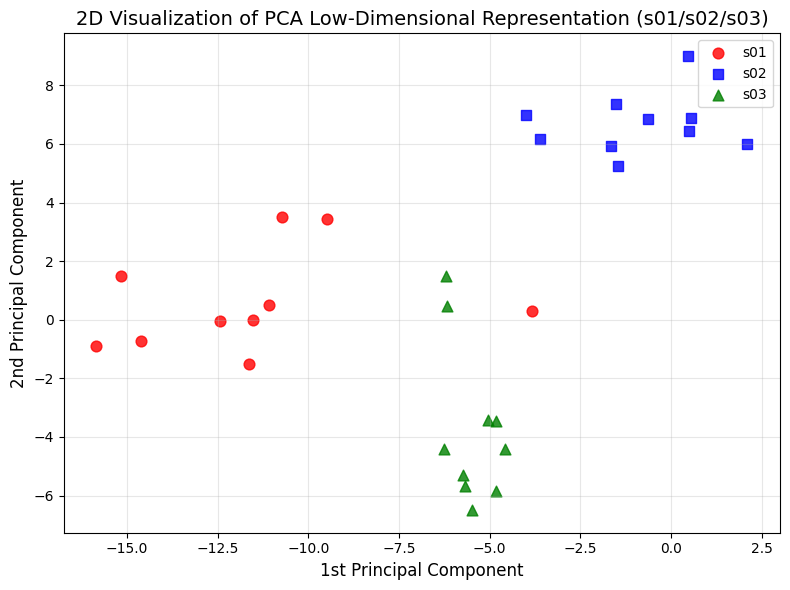

In [26]:
# TODO
## ---------- 请在以下输入代码 ---------- ##
## 绘制测试者低维度数据的显示
# 1. 筛选目标测试者（s01, s02, s03）的样本索引
target_persons = ['s01', 's02', 's03']
# 存储每个测试者对应的样本索引和颜色
person_indices = {
    's01': [],
    's02': [],
    's03': []
}

# 遍历faceLabels，找到目标测试者的样本索引
for idx, label in enumerate(faceLabels):
    person_id = label.split('/')[0]  # 从 "s01/0" 中提取 s01
    if person_id in target_persons:
        person_indices[person_id].append(idx)

# 2. 提取低维表示（用k=300的E2，取前2个维度）
# E2维度：(300, 389) → 取前2行作为x/y轴
emb_2d = E2[:2, :]  # 前2个主成分维度

# 3. 绘制散点图
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green']  # 为每个测试者分配不同颜色
markers = ['o', 's', '^']         # 为每个测试者分配不同标记

for i, person_id in enumerate(target_persons):
    # 提取该测试者的所有样本索引
    indices = person_indices[person_id]
    # 提取对应样本的前2维数据
    x = emb_2d[0, indices]
    y = emb_2d[1, indices]
    # 绘制散点图
    plt.scatter(x, y, color=colors[i], marker=markers[i], 
                label=person_id, alpha=0.8, s=60)

# 4. 图表美化
plt.xlabel('1st Principal Component', fontsize=12)
plt.ylabel('2nd Principal Component', fontsize=12)
plt.title('2D Visualization of PCA Low-Dimensional Representation (s01/s02/s03)', fontsize=14)
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
pass

上图表面，在PCA变换后的特征空间内，三名不同的测试者的照片具有一定的聚类相应。

## 6. 特征脸识别算法

由于特征脸矩阵对于数据集来说是恒定的，一个变化的特征向量 $e$ 意味着一个变化的人脸图像。因此我们可以预期，同一个人的图片会提供相似的权重向量，即使这些图片并不完全相同。

为此，我们可以利用两个权重向量之间的距离（例如L2范数）作为衡量两张图片相似度的指标，来构建基于特征脸的人脸识别算法。


In [35]:
k = 50                          # 选取 50 个特征脸
U = eigVecs[:, :k]                # 特征空间
E = np.matmul(U.T, meanA)         # 低维表示

到目前为止，我们的面部识别系统基本模块都已经完成。我们使用了39个人的图片来构建我们的特征脸。我们使用属于这39个人之一的测试图片（即从训练PCA模型的矩阵中保留出来的那一个）来查看它是否能够成功识别出人脸：


In [36]:
# Test on out-of-sample image of existing class
query = facesDict['s39'][9].reshape(-1, 1)

# TODO
## ---------- 请在以下输入代码 ---------- ##
# 先将特征空间U和低维表示E转为实数（剔除数值计算产生的虚部）
U = np.real(U)  # 特征空间 (10304, 50)
E = np.real(E)  # 训练样本的低维表示 (50, 389)
query = np.real(query)
# 1. 对查询图片做去中心化（减去平均脸）
query_centered = query - meanFace.flatten().reshape(-1, 1)
# 2. 将查询图片投影到特征空间，得到低维嵌入向量
query_embedding = np.matmul(U.T, query_centered)  
# 3. 计算查询向量与所有训练样本的欧氏距离（L2范数）
euclidean_distance = np.linalg.norm(E - query_embedding, axis=0)  # 维度：(389,)
# 4. 找到距离最小的样本（最佳匹配）
best_match = np.argmin(euclidean_distance)

print("Best match %s with Euclidean distance %f" % (faceLabels[best_match], euclidean_distance[best_match]))


Best match s39/5 with Euclidean distance 7.424150


在上面的步骤中，我们首先将向量化的图像减去从PCA结果中获取的平均向量。然后我们计算这个减去均值的向量在每个特征脸上的投影，并将其作为这张图片的权重。

之后，我们将所讨论图片的权重向量与每张现有图片的权重向量进行比较，并找到L2距离最小的那个作为最佳匹配。我们可以看到，它确实能够在同一个类别中成功找到最接近的匹配。

我们可以通过将最接近的匹配项并排比较来可视化结果。


Text(0.5, 1.0, 'Best match')

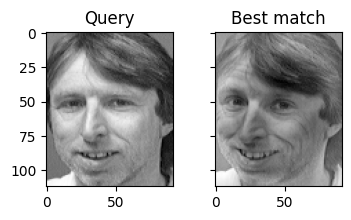

In [37]:

fig, axes = plt.subplots(1,2,sharex=True,sharey=True,figsize=(4, 2))

axes[0].imshow(query.reshape(featDim2D), cmap="gray")
axes[0].set_title("Query")
axes[1].imshow(meanA[:, best_match].reshape(featDim2D), cmap="gray")
axes[1].set_title("Best match")


我们可以尝试使用我们从PCA中保留出来的第40个人的图片。我们的模型永远不会正确识别它，因为这是一个新的人。然而，我们也想看看它能错到什么程度，以及距离指标的数值是多少。


In [38]:
# Test on out-of-sample image of new class
query = facesDict["s40"][0].reshape(-1, 1)

# TODO
## ---------- 请在以下输入代码 ---------- ##
query = np.real(query)
# 1. 对新类别查询图片去中心化（减去平均脸）
query_centered = query - meanFace.flatten().reshape(-1, 1)
# 2. 计算查询图片的低维嵌入向量（修正拼写错误：embeding→embedding）
query_embedding = np.matmul(U.T, query_centered)
# 3. 计算与所有训练样本的欧氏距离（L2范数）
euclidean_distance = np.linalg.norm(E - query_embedding, axis=0)
# 4. 找到距离最小的匹配（错误匹配）
best_match = np.argmin(euclidean_distance)

print("Best match %s with Euclidean distance %f" % (faceLabels[best_match], euclidean_distance[best_match]))

Best match s18/1 with Euclidean distance 11.654636


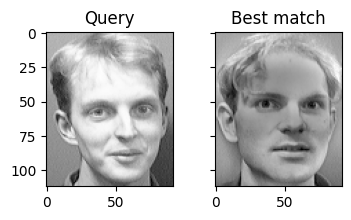

In [39]:
# Visualize
fig, axes = plt.subplots(1,2,sharex=True,sharey=True,figsize=(4, 2))
axes[0].imshow(query.reshape(featDim2D), cmap="gray")
axes[0].set_title("Query")
axes[1].imshow(meanA[:, best_match].reshape(featDim2D), cmap="gray")
axes[1].set_title("Best match")
plt.show()

但我们可以看到，错误结果与所讨论的图片有一些相似之处。

在Turk和Pentland的论文中，他们建议我们为L2距离设置一个阈值。如果最佳匹配的距离小于这个阈值，我们就会认为这张脸被识别为同一个人。如果距离超过阈值，我们就会声称这张图片是我们从未见过的人，即使可以数值上找到最佳匹配。在这种情况下，我们可能会考虑将这个新的人脸作为新人加入到我们的模型中，通过记住这个新的权重向量。

在下面，我们使用随机权重向量生成了一个，并与“平均脸”并排显示：。


Text(0.5, 1.0, 'Random face')

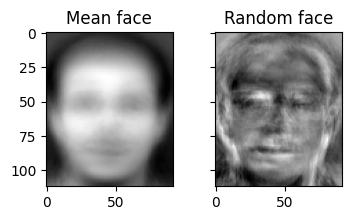

In [40]:
# Visualize the mean face and random face
fig, axes = plt.subplots(1,2,sharex=True,sharey=True,figsize=(4, 2))

axes[0].imshow(meanFace.reshape(featDim2D), cmap="gray")
axes[0].set_title("Mean face")

random_weights = np.random.randn(k) * U.std()
newface = np.matmul(U, random_weights) 
axes[1].imshow(newface.reshape(featDim2D), cmap="gray")
axes[1].set_title("Random face")

## 7. 讨论

特征脸的效果如何？对于模型的简单性来说，它的性能出乎意料地超过了预期。

然而，Turk和Pentland在各种条件下对其进行了测试。他们发现，在光线变化下的准确率为“平均96%”，在方向变化下的准确率为“85%”，在尺寸变化下的准确率为“64%”。

因此，它作为一个面部识别系统可能并不是很实用。毕竟，图片作为矩阵在主成分域中，在放大和缩小后会有很大的失真。因此，现代的替代方案是使用卷积神经网络，它对各种变换更有鲁棒性。


## 8. Sklearn中的PCA库函数的使用

**函数的定义**

```python
class sklearn.decomposition.PCA(n_components=None, *, copy=True, whiten=False, svd_solver='auto', tol=0.0, iterated_power='auto', n_oversamples=10, power_iteration_normalizer='auto', random_state=None)
```

- n_components：指定PCA降维后的特征维度数目。
    - 最常用的做法是直接指定降维到的维度数目，此时n_components是一个大于等于1的整数。
    
    - 我们也可以指定主成分的方差和所占的最小比例阈值，让PCA类自己去根据样本特征方差来决定降维到的维度数，此时n_components是一个（0，1]之间的数
    
    - 我们还可以将参数设置为"mle", 此时PCA类会用MLE算法根据特征的方差分布情况自己去选择一定数量的主成分特征来降维。
    
    - 我们也可以用默认值，即不输入n_components，此时n_components=min(样本数，特征数)。

- whiten ：判断是否进行白化。即对降维后的数据的每个特征进行归一化，让方差都为1.

- svd_solver：即指定奇异值分解SVD的方法，由于特征分解是奇异值分解SVD的一个特例，一般的PCA库都是基于SVD实现的。


In [41]:
# 使用 sklearn 中的PCA函数
from sklearn.decomposition import PCA

pca = PCA(n_components=300)
pca.fit(meanA.T)            # 输入数据 (n_samples, n_features)

PCA(n_components=300)

In [42]:
# 输出前三个特征值的比例
print(pca.explained_variance_ratio_, '\n')

# 输出前三个特征值
print(pca.explained_variance_, '\n')

# 输出前三个特征值对应的特征向量
print(pca.components_)

[0.17593681 0.14142661 0.06900377 0.05366752 0.04451873 0.03547192
 0.02305421 0.02204119 0.01902249 0.0157795  0.01549096 0.01392446
 0.01179283 0.01058328 0.00971216 0.00874382 0.00842928 0.00830601
 0.00771324 0.00704367 0.00673591 0.00643758 0.00585576 0.00553853
 0.00518929 0.0048325  0.00477997 0.0046306  0.00450756 0.00427608
 0.00411724 0.004005   0.00391594 0.00381457 0.00371832 0.00357695
 0.00346521 0.00324105 0.0032249  0.00298084 0.00286502 0.00283827
 0.00278393 0.00265236 0.00263433 0.00252997 0.00246538 0.00245755
 0.00238055 0.00234899 0.00229955 0.00224128 0.00219674 0.00215241
 0.00209758 0.00205868 0.0020148  0.00196644 0.00191118 0.00185961
 0.00180889 0.00180197 0.00172528 0.00168897 0.00166122 0.00163746
 0.00158014 0.00155024 0.00153314 0.00151225 0.00151063 0.00145363
 0.00144282 0.0014262  0.00141426 0.00138302 0.00137469 0.00133707
 0.00132643 0.00130548 0.00128153 0.00126986 0.00125783 0.00123069
 0.00121898 0.00119664 0.00117938 0.00116947 0.00114668 0.0011

### 8.1 绘制特征脸

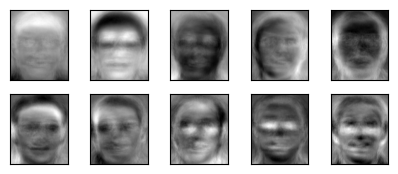

In [43]:
# 绘制前10个特征脸
fig, axes = plt.subplots(2, 5, figsize=(5, 2))

for ax, idx in zip(axes.flatten(), range(10)):
    ax.imshow(pca.components_[idx].reshape(featDim2D), cmap='gray')
    ax.set(xticks=[], yticks=[])

### 8.2 原始数据的低维表示

pca可以将原始数据投影到低维度空间，从而降低数据的维度。

In [44]:
# 原始数据在特征空间的投影
meanA_reduced_inv = pca.transform(meanA.T)
meanA_reduced = meanA_reduced_inv.T

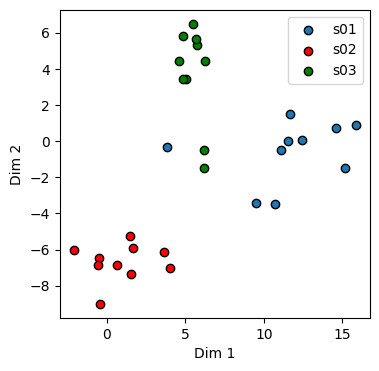

In [45]:
fig, ax = plt.subplots(figsize=(4, 4))

# TODO
## ---------- 请在补全输入代码，完成数据的低维显示 ---------- ##
ax.scatter(meanA_reduced[0, :10], meanA_reduced[1, :10], edgecolor='k', label='s01')
ax.scatter(meanA_reduced[0, 10:20], meanA_reduced[1, 10:20], edgecolor='k', color='r', label='s02')
ax.scatter(meanA_reduced[0, 20:30], meanA_reduced[1, 20:30], edgecolor='k', color='g', label='s03')

ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.legend();

### 8.3 原始数据的重构

In [46]:
meanA_recovered_inv = pca.inverse_transform(meanA_reduced_inv)
meanA_recovered = meanA_recovered_inv.T

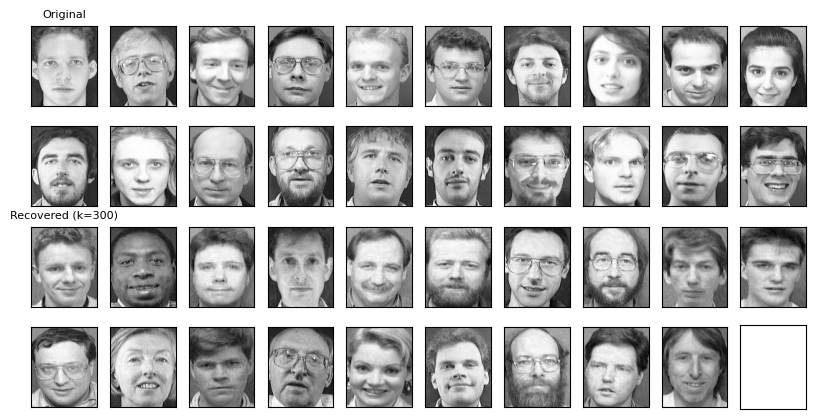

In [48]:
# draw recovered pictures
fig, axes = plt.subplots(4, 10, figsize=(10, 5))
for ax, jdx in zip(axes.flatten(), np.arange(0, 390, 10)):

    # TODO
    ## ---------- 请在补全输入代码，完成重构图片的显示 ---------- ##
    # 获取当前子图在flatten列表中的索引
    flat_idx = list(axes.flatten()).index(ax)
    # 计算行索引（4行10列）
    row_idx = flat_idx // 10  # 整除10得到行号（0,1,2,3）
    # 计算列索引
    col_idx = flat_idx % 10   # 取余10得到列号（0-9）
    
    # 2. 前2行：显示原始图片（从bigA取未去中心化的原始数据）
    if row_idx < 2:
        original_face = bigA[:, jdx].reshape(featDim2D)
        ax.imshow(original_face, cmap='gray')
        # 仅第一行第一列标注标题
        if row_idx == 0 and col_idx == 0:
            ax.set_title('Original', fontsize=8)
    # 3. 后2行：显示重构图片（加回平均脸恢复真实尺度）
    else:
        recovered_face = (meanA_recovered[:, jdx] + meanFace.flatten()).reshape(featDim2D)
        ax.imshow(recovered_face, cmap='gray')
        # 仅第三行第一列标注标题
        if row_idx == 2 and col_idx == 0:
            ax.set_title('Recovered (k=300)', fontsize=8)
    ax.set(xticks=[], yticks=[])
axes[-1, -1].set(xticks=[], yticks=[]);

## 自主实验题

针对sklearn中的wine recognition dataset，使用PCA完成以下操作：

    1. 使用两个主成分，完成数据的PCA分解
    2. 绘制降维后的原始数据表示
    3. 使用这两个主成分对原始数据进行重构 

wine数据资料：

[https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset)

=== 1. PCA分解结果 ===
原始数据维度：(178, 13) → 降维后维度：(178, 2)
主成分1方差解释率：0.3620
主成分2方差解释率：0.1921
累计方差解释率：0.5541


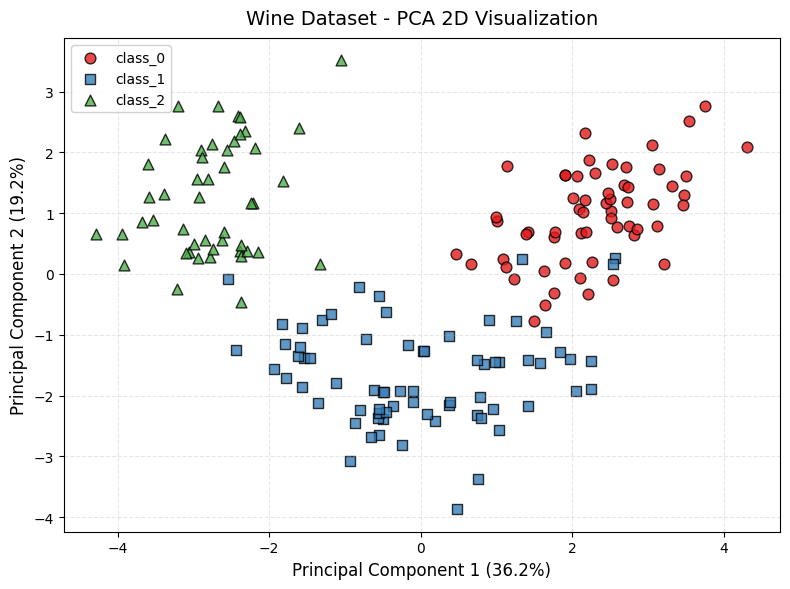


=== 3. 数据重构结果 ===
原始数据形状：(178, 13)
重构数据形状：(178, 13)
重构均方误差（MSE）：2139.7050


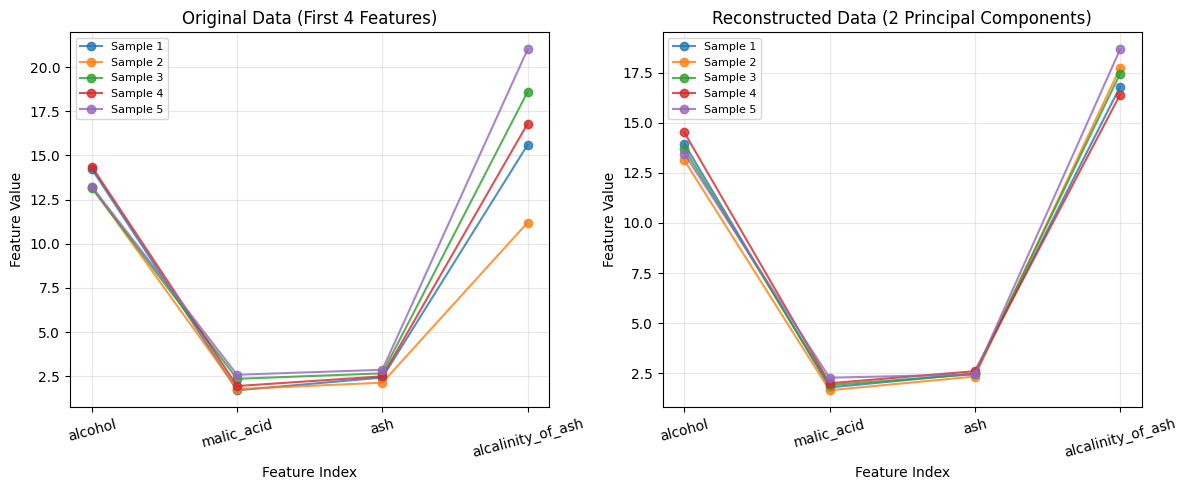

In [49]:
# 导入所需库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# ===================== 步骤1：数据导入 =====================
wine = load_wine()
target_names = wine.target_names    # 类别名称
X, y = wine.data, wine.target       # 获取训练数据X, 标签y
feature_names = wine.feature_names  # 补充特征名称，便于后续解释

# PCA对尺度敏感，必须标准化（均值0，方差1）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ===================== 步骤2：使用2个主成分完成PCA分解 =====================
# 初始化PCA，指定2个主成分
pca = PCA(n_components=2)
# 拟合并转换数据（降维到2维）
X_pca = pca.fit_transform(X_scaled)

# 输出关键信息，验证分解效果
print("=== 1. PCA分解结果 ===")
print(f"原始数据维度：{X.shape} → 降维后维度：{X_pca.shape}")
print(f"主成分1方差解释率：{pca.explained_variance_ratio_[0]:.4f}")
print(f"主成分2方差解释率：{pca.explained_variance_ratio_[1]:.4f}")
print(f"累计方差解释率：{np.sum(pca.explained_variance_ratio_):.4f}")

# ===================== 步骤3：绘制降维后的原始数据表示 =====================
plt.figure(figsize=(8, 6))
# 定义颜色/标记区分3类葡萄酒
colors = ['#e41a1c', '#377eb8', '#4daf4a']  # 更美观的配色
markers = ['o', 's', '^']

for i, name in enumerate(target_names):
    # 筛选对应类别的数据点
    mask = y == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], marker=markers[i],
                label=name, alpha=0.8, edgecolors='k', s=60)

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Wine Dataset - PCA 2D Visualization', fontsize=14, pad=10)
plt.legend(loc='best', framealpha=0.9)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ===================== 步骤4：使用2个主成分重构原始数据 =====================
# 逆变换重构数据（从2维还原回13维）
X_reconstructed = pca.inverse_transform(X_pca)
# 反标准化，恢复原始数据尺度
X_reconstructed = scaler.inverse_transform(X_reconstructed)

# 验证重构效果
print("\n=== 3. 数据重构结果 ===")
print(f"原始数据形状：{X.shape}")
print(f"重构数据形状：{X_reconstructed.shape}")
# 计算重构误差（均方误差）
mse = np.mean((X - X_reconstructed) **2)
print(f"重构均方误差（MSE）：{mse:.4f}")

# 可视化原始数据与重构数据的对比（选前5个样本的前4个特征）
plt.figure(figsize=(12, 5))
sample_ids = [0, 1, 2, 3, 4]  # 选前5个样本
feat_ids = [0, 1, 2, 3]       # 选前4个特征（便于对比）

# 子图1：原始数据
plt.subplot(1, 2, 1)
for idx in sample_ids:
    plt.plot(feat_ids, X[idx, feat_ids], 'o-', label=f'Sample {idx+1}', alpha=0.8)
plt.title('Original Data (First 4 Features)', fontsize=12)
plt.xlabel('Feature Index')
plt.ylabel('Feature Value')
plt.xticks(feat_ids, [feature_names[i] for i in feat_ids], rotation=15)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# 子图2：重构数据
plt.subplot(1, 2, 2)
for idx in sample_ids:
    plt.plot(feat_ids, X_reconstructed[idx, feat_ids], 'o-', label=f'Sample {idx+1}', alpha=0.8)
plt.title('Reconstructed Data (2 Principal Components)', fontsize=12)
plt.xlabel('Feature Index')
plt.ylabel('Feature Value')
plt.xticks(feat_ids, [feature_names[i] for i in feat_ids], rotation=15)
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()